# Statistical Significance Testing

This notebook performs rigorous statistical tests to validate model performance and key findings:

**Section 1 – Model Validation (original)**
1. Permutation test: accuracy significantly > chance
2. Bootstrap confidence intervals: reliability of accuracy/F1
3. McNemar's test: pairwise model comparisons
4. Repeated-measures ANOVA: ambiguity effect on accuracy

**Section 5 – Cross-Visit Generalization**
5. Paired t-test: V1→V2 cross-visit accuracy vs. within-visit LOSO
6. Modality ablation: which features drive generalization

**Section 6 – Aversion–Gaze Coupling**
7. Spearman correlation: ambiguity aversion ↔ gaze coupling
8. Paired t-test: V1→V2 change in aversion and coupling

**Section 7 – Modality Shapley Values by Condition**
9. Permutation test on Shapley % contributions: ambiguity × modality
10. Permutation test: RT group × modality Shapley

**Parameterized**: Set `TIMEFRAME` to run PRE or POST analysis.

In [1]:
# ============================================================================
# CONFIGURATION: Set timeframe for analysis
# ============================================================================
TIMEFRAME = 'PRE'  # Options: 'PRE', 'POST'
# ============================================================================

print(f"\n{'='*70}")
print(f"STATISTICAL SIGNIFICANCE TESTING: {TIMEFRAME}-DECISION PERIOD")
print(f"{'='*70}\n")


STATISTICAL SIGNIFICANCE TESTING: PRE-DECISION PERIOD



In [2]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_style('whitegrid')
np.random.seed(42)

## Load Decision Results

In [3]:
# Load features
with open(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', 'rb') as f:
    feature_data = pickle.load(f)

data = feature_data['merged_df']

print(f"Total trials: {len(data)}")
print(f"Subjects: {data['subject_id'].nunique()}")
print(f"Outcome distribution: {data['outcome'].value_counts().to_dict()}")
print(f"\nClass balance: {data['outcome'].value_counts()[0]/len(data):.1%} / {data['outcome'].value_counts()[1]/len(data):.1%}")
print(f"\n⚠️  NOTE: Using class_weight='balanced' to handle class imbalance")
print(f"   This will give different results than other notebooks without class balancing")

Total trials: 12107
Subjects: 102
Outcome distribution: {1: 7910, 0: 4197}

Class balance: 34.7% / 65.3%

⚠️  NOTE: Using class_weight='balanced' to handle class imbalance
   This will give different results than other notebooks without class balancing


## 1. Permutation Test: Better Than Chance?

**Null hypothesis:** Model accuracy = 50% (chance)

**Method:** Shuffle labels 1000 times, recompute accuracy, compare to observed

In [4]:
def permutation_test(X, y, subjects, n_permutations=1000, model_name="Model"):
    """
    Optimized permutation test to assess if accuracy is significantly > chance.
    
    Uses class_weight='balanced' to handle class imbalance properly.
    Tests against 50% random chance baseline.
    """
    print(f"\n{'='*70}")
    print(f"Permutation Test: {model_name}")
    print(f"{'='*70}")
    
    # Get true accuracy using LOSO CV
    logo = LeaveOneGroupOut()
    true_accs = []
    
    print("Computing true accuracy with class_weight='balanced'...")
    for train_idx, test_idx in tqdm(logo.split(X, y, subjects), 
                                     total=len(np.unique(subjects)),
                                     desc="True LOSO folds"):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Use class_weight='balanced' to handle imbalance
        model = RandomForestClassifier(n_estimators=50, max_depth=5, 
                                      min_samples_split=10, min_samples_leaf=5,
                                      class_weight='balanced',
                                      random_state=42, n_jobs=1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        true_accs.append(accuracy_score(y_test, y_pred))
    
    true_accuracy = np.mean(true_accs)
    print(f"True Accuracy: {true_accuracy:.4f}")
    
    # Permutation test: shuffle labels to break feature-label relationship
    print(f"\nRunning {n_permutations} permutations...")
    print("Testing against 50% chance baseline (with balanced classes)")
    
    null_accs = []
    
    for i in tqdm(range(n_permutations), desc="Permutations"):
        # Randomly shuffle ALL labels (breaks feature-label relationship)
        y_shuffled = np.random.permutation(y)
        
        # Sample subset of subjects for speed
        unique_subjects = np.unique(subjects)
        sample_size = min(20, len(unique_subjects))
        sampled_subjects = np.random.choice(unique_subjects, size=sample_size, replace=False)
        sampled_mask = np.isin(subjects, sampled_subjects)
        
        X_sample = X[sampled_mask]
        y_sample = y_shuffled[sampled_mask]
        subjects_sample = subjects[sampled_mask]
        
        # Run LOSO CV with shuffled labels
        perm_accs = []
        for train_idx, test_idx in logo.split(X_sample, y_sample, subjects_sample):
            X_train, X_test = X_sample[train_idx], X_sample[test_idx]
            y_train, y_test = y_sample[train_idx], y_sample[test_idx]
            
            # Use class_weight='balanced'
            model = RandomForestClassifier(n_estimators=50, max_depth=5,
                                          min_samples_split=10, min_samples_leaf=5,
                                          class_weight='balanced',
                                          random_state=i, n_jobs=1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            perm_accs.append(accuracy_score(y_test, y_pred))
        
        null_accs.append(np.mean(perm_accs))
    
    # Compute p-value
    p_value = np.mean(np.array(null_accs) >= true_accuracy)
    
    print(f"\nNull Distribution Mean: {np.mean(null_accs):.4f} (should be ~50%)")
    print(f"Null Distribution Std: {np.std(null_accs):.4f}")
    print(f"True Accuracy: {true_accuracy:.4f}")
    print(f"\np-value: {p_value:.4f}")
    
    if p_value < 0.001:
        print(f"✓ {model_name} is HIGHLY SIGNIFICANT (p < 0.001)")
    elif p_value < 0.01:
        print(f"✓ {model_name} is VERY SIGNIFICANT (p < 0.01)")
    elif p_value < 0.05:
        print(f"✓ {model_name} is SIGNIFICANT (p < 0.05)")
    else:
        print(f"✗ {model_name} is NOT SIGNIFICANT (p = {p_value:.4f})")
    
    return {
        'true_accuracy': true_accuracy,
        'null_mean': np.mean(null_accs),
        'null_std': np.std(null_accs),
        'p_value': p_value,
        'null_distribution': null_accs
    }

In [5]:
# Define feature groups
if TIMEFRAME == 'PRE':
    physiology_features = [
        'pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 
        'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre',
        'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre',
        'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 
        'eye_asymmetry_std_pre'
    ]
else:
    physiology_features = [
        'pupil_mean_post', 'pupil_std_post', 'pupil_slope_post', 'time_to_peak_post', 
        'pupil_cv_post', 'pupil_velocity_mean_post', 'pupil_max_dilation_rate_post',
        'pupil_max_constriction_rate_post', 'pupil_acceleration_std_post',
        'pct_time_dilating_post', 'num_dilation_peaks_post', 'eye_asymmetry_post', 
        'eye_asymmetry_std_post'
    ]

gaze_features = [
    'gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std',
    'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std',
    'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max',
    'gaze_acceleration_mean', 'gaze_acceleration_std',
    'fixation_ratio', 'saccade_ratio', 'saccade_count',
    'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length'
]

behavior_features = [
    'reaction_time', 'decision_time', 'ev_difference',
    'invest_variance', 'ambiguity', 'condition_social', 'risk_premium'
]

# Filter available features
available_physiology = [f for f in physiology_features if f in data.columns]
available_gaze = [f for f in gaze_features if f in data.columns]
available_behavior = [f for f in behavior_features if f in data.columns]

print(f"Physiology features: {len(available_physiology)}/{len(physiology_features)}")
print(f"Gaze features: {len(available_gaze)}/{len(gaze_features)}")
print(f"Behavior features: {len(available_behavior)}/{len(behavior_features)}")

# Prepare data for all modalities
X_physiology = SimpleImputer(strategy='mean').fit_transform(data[available_physiology])
X_gaze = SimpleImputer(strategy='mean').fit_transform(data[available_gaze])
X_behavior = SimpleImputer(strategy='mean').fit_transform(data[available_behavior])
X_phys_gaze = SimpleImputer(strategy='mean').fit_transform(data[available_physiology + available_gaze])
X_all = SimpleImputer(strategy='mean').fit_transform(data[available_physiology + available_gaze + available_behavior])

y = data['outcome'].values
subjects = data['subject_id'].values

print(f"\nDataset shapes:")
print(f"  Physiology: {X_physiology.shape}")
print(f"  Gaze: {X_gaze.shape}")
print(f"  Behavior: {X_behavior.shape}")
print(f"  Physiology + Gaze: {X_phys_gaze.shape}")
print(f"  All features: {X_all.shape}")

Physiology features: 13/13
Gaze features: 20/20
Behavior features: 6/7

Dataset shapes:
  Physiology: (12107, 13)
  Gaze: (12107, 20)
  Behavior: (12107, 6)
  Physiology + Gaze: (12107, 33)
  All features: (12107, 39)


In [6]:
# Run permutation tests on all modalities
print("="*70)
print("RUNNING PERMUTATION TESTS FOR ALL MODALITIES")
print("="*70)

perm_results = {}

perm_results['all'] = permutation_test(
    X_all, y, subjects, 
    n_permutations=1000, 
    model_name=f"All Features ({TIMEFRAME})"
)

RUNNING PERMUTATION TESTS FOR ALL MODALITIES

Permutation Test: All Features (PRE)
Computing true accuracy with class_weight='balanced'...


True LOSO folds: 100%|██████████| 102/102 [01:46<00:00,  1.04s/it]


True Accuracy: 0.6788

Running 1000 permutations...
Testing against 50% chance baseline (with balanced classes)


Permutations: 100%|██████████| 1000/1000 [1:54:20<00:00,  6.86s/it]   


Null Distribution Mean: 0.5442 (should be ~50%)
Null Distribution Std: 0.0173
True Accuracy: 0.6788

p-value: 0.0000
✓ All Features (PRE) is HIGHLY SIGNIFICANT (p < 0.001)


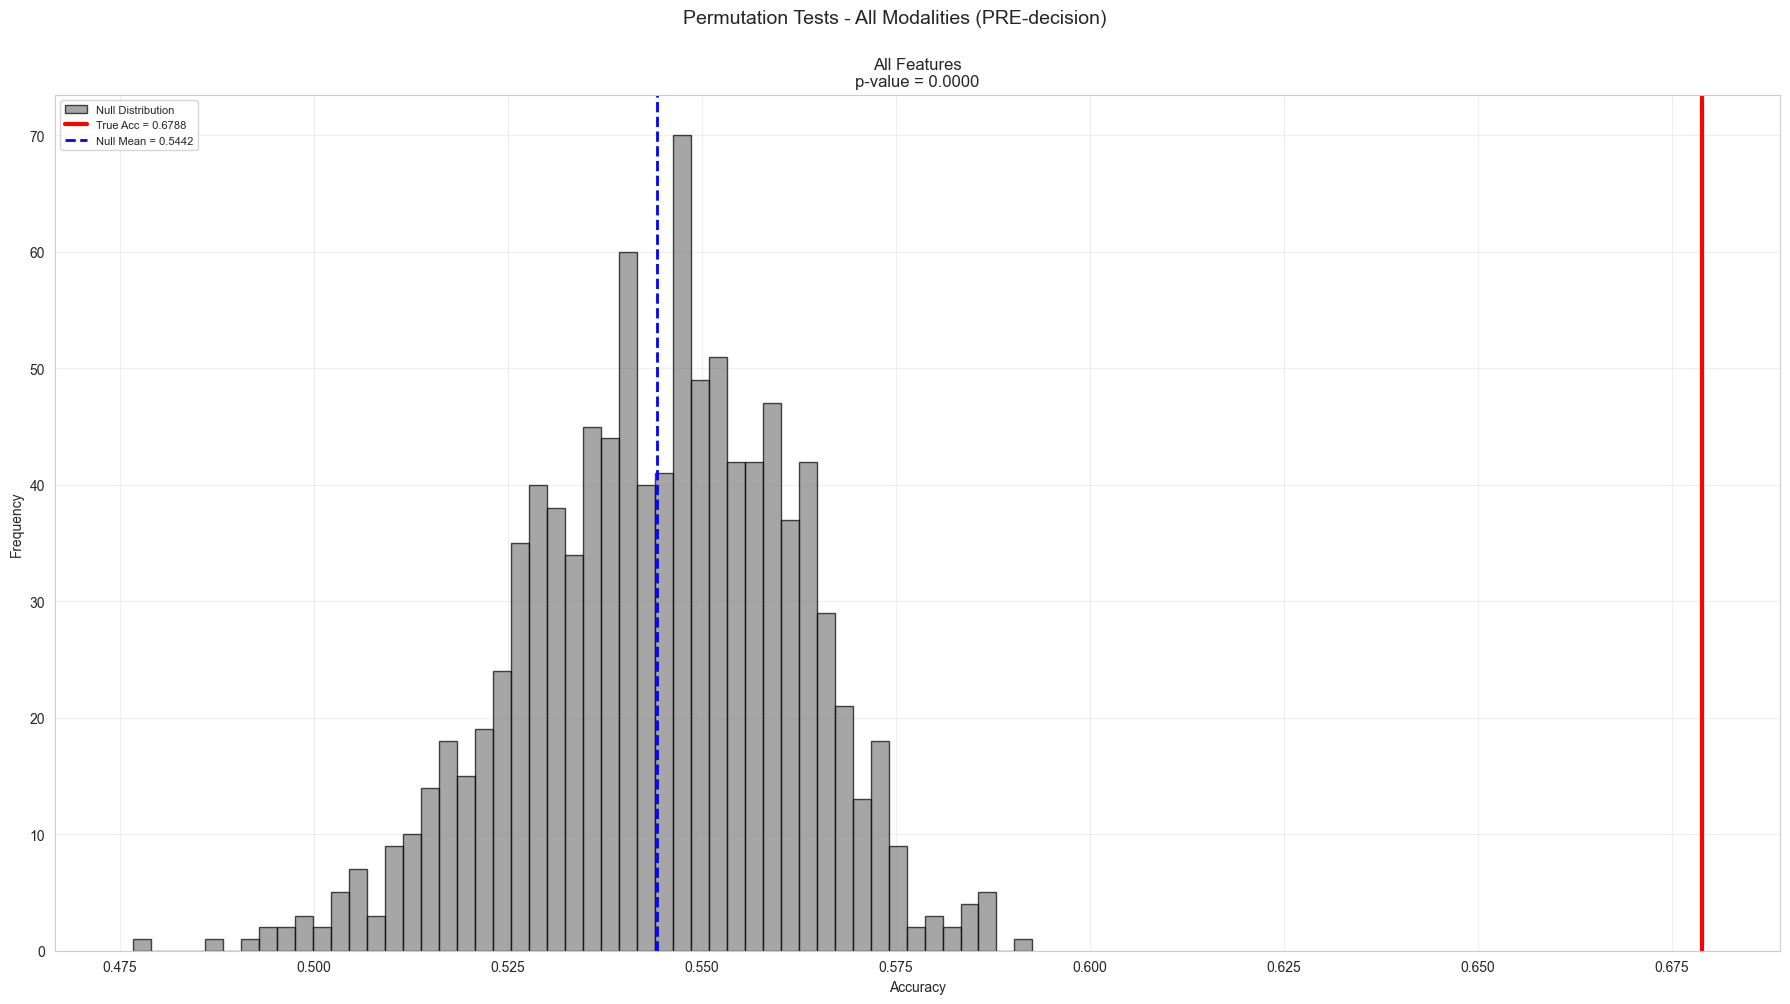


PERMUTATION TEST SUMMARY
       Model  True Accuracy  Null Mean  p-value Significant
All Features       0.678845    0.54416      0.0         Yes


In [7]:
# Visualize permutation tests for all modalities
fig, axes = plt.subplots(1, 1, figsize=(18, 10))

modalities = ['all']
titles = ['All Features']

for idx, (modality, title) in enumerate(zip(modalities, titles)):
    ax = axes
    result = perm_results[modality]
    
    ax.hist(result['null_distribution'], bins=50, alpha=0.7, 
            color='gray', edgecolor='black', label='Null Distribution')
    ax.axvline(result['true_accuracy'], color='red', linewidth=3, 
              label=f"True Acc = {result['true_accuracy']:.4f}")
    ax.axvline(result['null_mean'], color='blue', linewidth=2, 
              linestyle='--', label=f"Null Mean = {result['null_mean']:.4f}")
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Frequency')
    ax.set_title(f"{title}\np-value = {result['p_value']:.4f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Permutation Tests - All Modalities ({TIMEFRAME}-decision)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/permutation_tests_all_{TIMEFRAME}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*70)
print("PERMUTATION TEST SUMMARY")
print("="*70)
perm_summary = pd.DataFrame({
    'Model': titles,
    'True Accuracy': [perm_results[m]['true_accuracy'] for m in modalities],
    'Null Mean': [perm_results[m]['null_mean'] for m in modalities],
    'p-value': [perm_results[m]['p_value'] for m in modalities],
    'Significant': ['Yes' if perm_results[m]['p_value'] < 0.05 else 'No' for m in modalities]
})
print(perm_summary.to_string(index=False))

## 2. Bootstrap Confidence Intervals

**Goal:** Estimate 95% CI for accuracy and F1-score

**Method:** Resample subjects with replacement 1000 times

In [8]:
def bootstrap_ci(X, y, subjects, n_bootstrap=1000, model_name="Model"):
    """
    Optimized bootstrap confidence intervals for accuracy and F1-score.
    
    Uses class_weight='balanced' to handle class imbalance.
    """
    print(f"\n{'='*70}")
    print(f"Bootstrap Confidence Intervals: {model_name}")
    print(f"{'='*70}")
    
    unique_subjects = np.unique(subjects)
    n_subjects = len(unique_subjects)
    
    boot_accs = []
    boot_f1s = []
    
    # Sample ~30 subjects per bootstrap iteration for speed
    sample_size = min(30, n_subjects)
    
    print(f"Bootstrap strategy: Sampling {sample_size}/{n_subjects} subjects per iteration")
    print(f"Using class_weight='balanced' in all models")
    
    for i in tqdm(range(n_bootstrap), desc="Bootstrap iterations"):
        # Resample subjects with replacement
        boot_subjects = np.random.choice(unique_subjects, size=sample_size, replace=True)
        
        # Create bootstrap sample
        boot_mask = np.isin(subjects, boot_subjects)
        X_boot = X[boot_mask]
        y_boot = y[boot_mask]
        subjects_boot = subjects[boot_mask]
        
        # Skip if we don't have enough subjects
        if len(np.unique(subjects_boot)) < 5:
            continue
        
        # LOSO CV on bootstrap sample
        logo = LeaveOneGroupOut()
        fold_accs = []
        fold_f1s = []
        
        for train_idx, test_idx in logo.split(X_boot, y_boot, subjects_boot):
            X_train, X_test = X_boot[train_idx], X_boot[test_idx]
            y_train, y_test = y_boot[train_idx], y_boot[test_idx]
            
            # Skip folds with single class
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue
            
            # Use class_weight='balanced'
            model = RandomForestClassifier(n_estimators=50, max_depth=5,
                                          min_samples_split=10, min_samples_leaf=5,
                                          class_weight='balanced',
                                          random_state=i, n_jobs=1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            fold_accs.append(accuracy_score(y_test, y_pred))
            fold_f1s.append(f1_score(y_test, y_pred, average='weighted'))
        
        # Only add if we got valid results
        if len(fold_accs) > 0:
            boot_accs.append(np.mean(fold_accs))
            boot_f1s.append(np.mean(fold_f1s))
    
    # Compute 95% CI
    acc_ci = np.percentile(boot_accs, [2.5, 97.5])
    f1_ci = np.percentile(boot_f1s, [2.5, 97.5])
    
    print(f"\nCompleted {len(boot_accs)} valid bootstrap iterations")
    print(f"Accuracy: {np.mean(boot_accs):.4f} (95% CI: {acc_ci[0]:.4f}-{acc_ci[1]:.4f})")
    print(f"F1-Score: {np.mean(boot_f1s):.4f} (95% CI: {f1_ci[0]:.4f}-{f1_ci[1]:.4f})")
    
    return {
        'accuracy_mean': np.mean(boot_accs),
        'accuracy_ci': acc_ci,
        'f1_mean': np.mean(boot_f1s),
        'f1_ci': f1_ci,
        'boot_accs': boot_accs,
        'boot_f1s': boot_f1s
    }

In [9]:
# Run bootstrap for all modalities
print("="*70)
print("RUNNING BOOTSTRAP CONFIDENCE INTERVALS FOR ALL MODALITIES")
print("="*70)

boot_results = {}
boot_results['all'] = bootstrap_ci(
    X_all, y, subjects, 
    n_bootstrap=1000, 
    model_name=f"All Features ({TIMEFRAME})"
)

RUNNING BOOTSTRAP CONFIDENCE INTERVALS FOR ALL MODALITIES

Bootstrap Confidence Intervals: All Features (PRE)
Bootstrap strategy: Sampling 30/102 subjects per iteration
Using class_weight='balanced' in all models


Bootstrap iterations: 100%|██████████| 1000/1000 [1:42:11<00:00,  6.13s/it] 


Completed 1000 valid bootstrap iterations
Accuracy: 0.6591 (95% CI: 0.6092-0.7033)
F1-Score: 0.6612 (95% CI: 0.6063-0.7089)


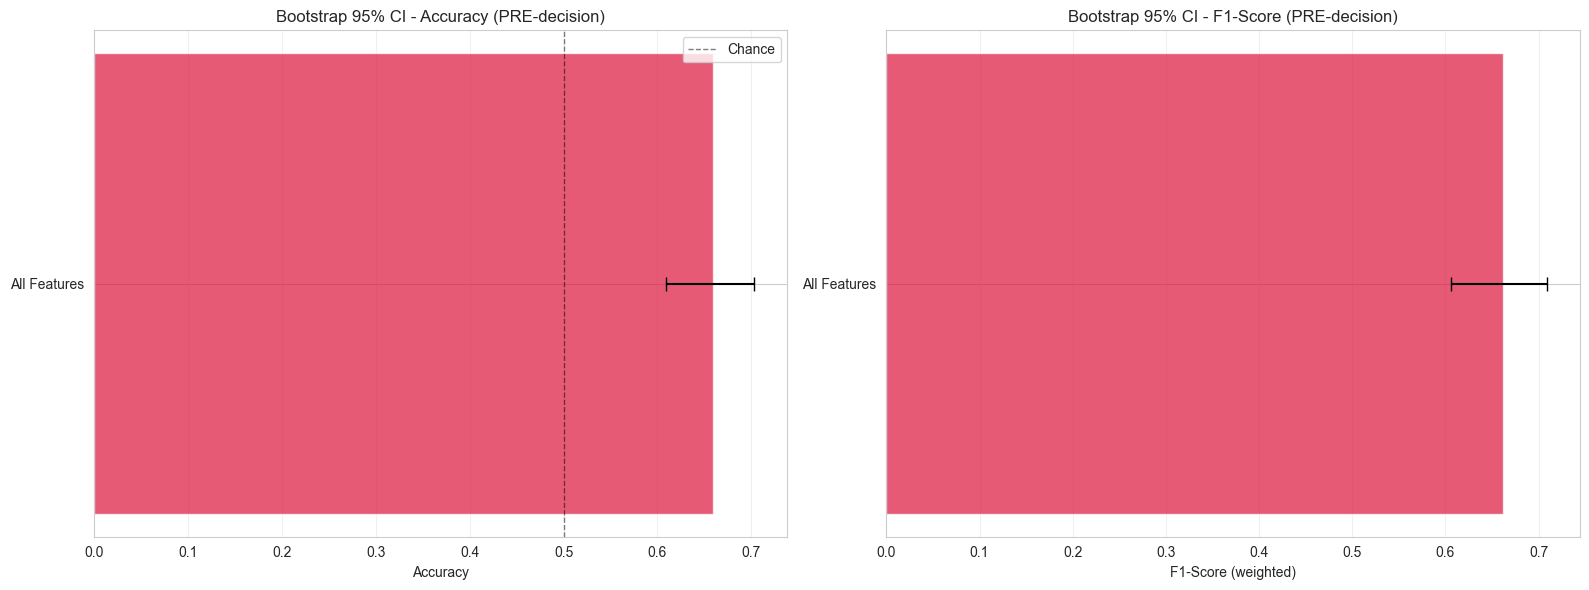


BOOTSTRAP CONFIDENCE INTERVALS SUMMARY
       Model Accuracy Accuracy 95% CI F1-Score       F1 95% CI
All Features   0.6591 (0.6092-0.7033)   0.6612 (0.6063-0.7089)


In [10]:
# Visualize bootstrap confidence intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

modalities = ['all']
titles = ['All Features']
colors = ['crimson']

# Accuracy plot
acc_means = [boot_results[m]['accuracy_mean'] for m in modalities]
acc_cis = [boot_results[m]['accuracy_ci'] for m in modalities]
acc_errors = [[acc_means[i] - acc_cis[i][0], acc_cis[i][1] - acc_means[i]] for i in range(len(modalities))]

ax1.barh(titles, acc_means, xerr=np.array(acc_errors).T, color=colors, alpha=0.7, capsize=5)
ax1.set_xlabel('Accuracy')
ax1.set_title(f'Bootstrap 95% CI - Accuracy ({TIMEFRAME}-decision)')
ax1.grid(True, alpha=0.3, axis='x')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Chance')
ax1.legend()

# F1-score plot
f1_means = [boot_results[m]['f1_mean'] for m in modalities]
f1_cis = [boot_results[m]['f1_ci'] for m in modalities]
f1_errors = [[f1_means[i] - f1_cis[i][0], f1_cis[i][1] - f1_means[i]] for i in range(len(modalities))]

ax2.barh(titles, f1_means, xerr=np.array(f1_errors).T, color=colors, alpha=0.7, capsize=5)
ax2.set_xlabel('F1-Score (weighted)')
ax2.set_title(f'Bootstrap 95% CI - F1-Score ({TIMEFRAME}-decision)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/bootstrap_ci_all_{TIMEFRAME}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS SUMMARY")
print("="*70)
boot_summary = pd.DataFrame({
    'Model': titles,
    'Accuracy': [f"{boot_results[m]['accuracy_mean']:.4f}" for m in modalities],
    'Accuracy 95% CI': [f"({boot_results[m]['accuracy_ci'][0]:.4f}-{boot_results[m]['accuracy_ci'][1]:.4f})" for m in modalities],
    'F1-Score': [f"{boot_results[m]['f1_mean']:.4f}" for m in modalities],
    'F1 95% CI': [f"({boot_results[m]['f1_ci'][0]:.4f}-{boot_results[m]['f1_ci'][1]:.4f})" for m in modalities]
})
print(boot_summary.to_string(index=False))

## 3. McNemar's Test: Compare Models

**Goal:** Test if differences between models are statistically significant

**Comparisons:**
1. Combined vs Behavior Only
2. Combined vs Gaze Only  
3. Combined vs Physiology Only
4. Behavior vs Gaze
5. Behavior vs Physiology
6. Gaze vs Physiology

In [11]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, pred_model1, pred_model2, model1_name, model2_name):
    """
    McNemar's test to compare two models.
    
    Tests whether the two models make significantly different errors.
    Null hypothesis: Both models have the same error rate.
    """
    # Create contingency table
    # Format: [[both_correct, model1_correct_model2_wrong],
    #          [model1_wrong_model2_correct, both_wrong]]
    
    both_correct = np.sum((pred_model1 == y_true) & (pred_model2 == y_true))
    model1_correct = np.sum((pred_model1 == y_true) & (pred_model2 != y_true))
    model2_correct = np.sum((pred_model1 != y_true) & (pred_model2 == y_true))
    both_wrong = np.sum((pred_model1 != y_true) & (pred_model2 != y_true))
    
    contingency_table = np.array([[both_correct, model1_correct],
                                  [model2_correct, both_wrong]])
    
    # Run McNemar's test
    result = mcnemar(contingency_table, exact=False, correction=True)
    
    # Calculate accuracies
    acc1 = accuracy_score(y_true, pred_model1)
    acc2 = accuracy_score(y_true, pred_model2)
    
    print(f"\n{'='*70}")
    print(f"McNemar's Test: {model1_name} vs {model2_name}")
    print(f"{'='*70}")
    print(f"\nModel Accuracies:")
    print(f"  {model1_name}: {acc1:.4f}")
    print(f"  {model2_name}: {acc2:.4f}")
    print(f"  Difference: {abs(acc1 - acc2):.4f}")
    print(f"\nContingency Table:")
    print(f"  Both correct: {both_correct}")
    print(f"  Only {model1_name} correct: {model1_correct}")
    print(f"  Only {model2_name} correct: {model2_correct}")
    print(f"  Both wrong: {both_wrong}")
    print(f"\nMcNemar Test Results:")
    print(f"  Test statistic: {result.statistic:.4f}")
    print(f"  p-value: {result.pvalue:.4f}")
    
    if result.pvalue < 0.001:
        print(f"✓ Difference is HIGHLY SIGNIFICANT (p < 0.001)")
    elif result.pvalue < 0.01:
        print(f"✓ Difference is VERY SIGNIFICANT (p < 0.01)")
    elif result.pvalue < 0.05:
        print(f"✓ Difference is SIGNIFICANT (p < 0.05)")
    else:
        print(f"✗ Difference is NOT SIGNIFICANT (p = {result.pvalue:.4f})")
    
    return {
        'statistic': result.statistic,
        'pvalue': result.pvalue,
        'contingency_table': contingency_table,
        'acc1': acc1,
        'acc2': acc2
    }

## Generate Predictions for All Models

We need predictions from all models to run McNemar's test comparisons.

In [12]:
# Generate predictions from all models using LOSO CV
from sklearn.model_selection import LeaveOneGroupOut

def get_model_predictions(X, y, subjects):
    """Get predictions from LOSO cross-validation with class_weight='balanced'."""
    logo = LeaveOneGroupOut()
    model = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                  min_samples_split=10, min_samples_leaf=5,
                                  class_weight='balanced',
                                  random_state=42, n_jobs=-1)
    
    preds_all = []
    y_true_all = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        preds_all.extend(y_pred)
        y_true_all.extend(y_test)
    
    return np.array(preds_all), np.array(y_true_all)

print("Generating predictions for all models...")
print("⚠️  Using class_weight='balanced' (different from other notebooks!)")
print("This will take several minutes...\n")

# Generate predictions for all modalities
pred_physio, y_true = get_model_predictions(X_physiology, y, subjects)
print(f"✓ Physiology model - Accuracy: {accuracy_score(y_true, pred_physio):.4f}")

pred_gaze, _ = get_model_predictions(X_gaze, y, subjects)
print(f"✓ Gaze model - Accuracy: {accuracy_score(y_true, pred_gaze):.4f}")

pred_behavior, _ = get_model_predictions(X_behavior, y, subjects)
print(f"✓ Behavior model - Accuracy: {accuracy_score(y_true, pred_behavior):.4f}")

pred_phys_gaze, _ = get_model_predictions(X_phys_gaze, y, subjects)
print(f"✓ Physiology + Gaze model - Accuracy: {accuracy_score(y_true, pred_phys_gaze):.4f}")

pred_all, _ = get_model_predictions(X_all, y, subjects)
print(f"✓ All features model - Accuracy: {accuracy_score(y_true, pred_all):.4f}")

print("\n✓ All predictions generated!")
print("\n⚠️  Remember to add class_weight='balanced' to all other modeling notebooks!")

Generating predictions for all models...
⚠️  Using class_weight='balanced' (different from other notebooks!)
This will take several minutes...

✓ Physiology model - Accuracy: 0.5158
✓ Gaze model - Accuracy: 0.6172
✓ Behavior model - Accuracy: 0.6603
✓ Physiology + Gaze model - Accuracy: 0.6058
✓ All features model - Accuracy: 0.6853

✓ All predictions generated!

⚠️  Remember to add class_weight='balanced' to all other modeling notebooks!


In [13]:
# Run all pairwise comparisons
print("\n" + "="*70)
print("MCNEMAR'S TESTS: PAIRWISE MODEL COMPARISONS")
print("="*70)

# Store all results
mcnemar_results = {}

# 1. All Features vs individual modalities
mcnemar_results['all_vs_physio'] = mcnemar_test(
    y_true, pred_all, pred_physio, 
    "All Features", "Physiology"
)

mcnemar_results['all_vs_gaze'] = mcnemar_test(
    y_true, pred_all, pred_gaze,
    "All Features", "Gaze"
)

mcnemar_results['all_vs_behavior'] = mcnemar_test(
    y_true, pred_all, pred_behavior, 
    "All Features", "Behavior"
)

mcnemar_results['all_vs_phys_gaze'] = mcnemar_test(
    y_true, pred_all, pred_phys_gaze,
    "All Features", "Physiology+Gaze"
)

# 2. Physiology+Gaze vs individual modalities
mcnemar_results['phys_gaze_vs_physio'] = mcnemar_test(
    y_true, pred_phys_gaze, pred_physio,
    "Physiology+Gaze", "Physiology"
)

mcnemar_results['phys_gaze_vs_gaze'] = mcnemar_test(
    y_true, pred_phys_gaze, pred_gaze,
    "Physiology+Gaze", "Gaze"
)

mcnemar_results['phys_gaze_vs_behavior'] = mcnemar_test(
    y_true, pred_phys_gaze, pred_behavior,
    "Physiology+Gaze", "Behavior"
)

# 3. Between individual modalities
mcnemar_results['physio_vs_gaze'] = mcnemar_test(
    y_true, pred_physio, pred_gaze,
    "Physiology", "Gaze"
)

mcnemar_results['physio_vs_behavior'] = mcnemar_test(
    y_true, pred_physio, pred_behavior,
    "Physiology", "Behavior"
)

mcnemar_results['gaze_vs_behavior'] = mcnemar_test(
    y_true, pred_gaze, pred_behavior,
    "Gaze", "Behavior"
)


MCNEMAR'S TESTS: PAIRWISE MODEL COMPARISONS

McNemar's Test: All Features vs Physiology

Model Accuracies:
  All Features: 0.6853
  Physiology: 0.5158
  Difference: 0.1695

Contingency Table:
  Both correct: 4911
  Only All Features correct: 3386
  Only Physiology correct: 1334
  Both wrong: 2476

McNemar Test Results:
  Test statistic: 891.2290
  p-value: 0.0000
✓ Difference is HIGHLY SIGNIFICANT (p < 0.001)

McNemar's Test: All Features vs Gaze

Model Accuracies:
  All Features: 0.6853
  Gaze: 0.6172
  Difference: 0.0681

Contingency Table:
  Both correct: 6547
  Only All Features correct: 1750
  Only Gaze correct: 926
  Both wrong: 2884

McNemar Test Results:
  Test statistic: 253.1125
  p-value: 0.0000
✓ Difference is HIGHLY SIGNIFICANT (p < 0.001)

McNemar's Test: All Features vs Behavior

Model Accuracies:
  All Features: 0.6853
  Behavior: 0.6603
  Difference: 0.0250

Contingency Table:
  Both correct: 6805
  Only All Features correct: 1492
  Only Behavior correct: 1189
  Both 


MCNEMAR'S TEST SUMMARY
                     Comparison  Accuracy_1  Accuracy_2  Difference       p_value Significant
     All Features vs Physiology    0.685306    0.515817    0.169489 7.916542e-196         Yes
           All Features vs Gaze    0.685306    0.617246    0.068060  5.443862e-57         Yes
       All Features vs Behavior    0.685306    0.660279    0.025027  5.458635e-09         Yes
All Features vs Physiology+Gaze    0.685306    0.605848    0.079458  2.949461e-76         Yes
  Physiology+Gaze vs Physiology    0.605848    0.515817    0.090031  3.633951e-68         Yes
        Physiology+Gaze vs Gaze    0.605848    0.617246    0.011398  2.167472e-04         Yes
    Physiology+Gaze vs Behavior    0.605848    0.660279    0.054431  9.119831e-21         Yes
             Physiology vs Gaze    0.515817    0.617246    0.101429  2.267160e-67         Yes
         Physiology vs Behavior    0.515817    0.660279    0.144462 3.444269e-120         Yes
               Gaze vs Behavior    0

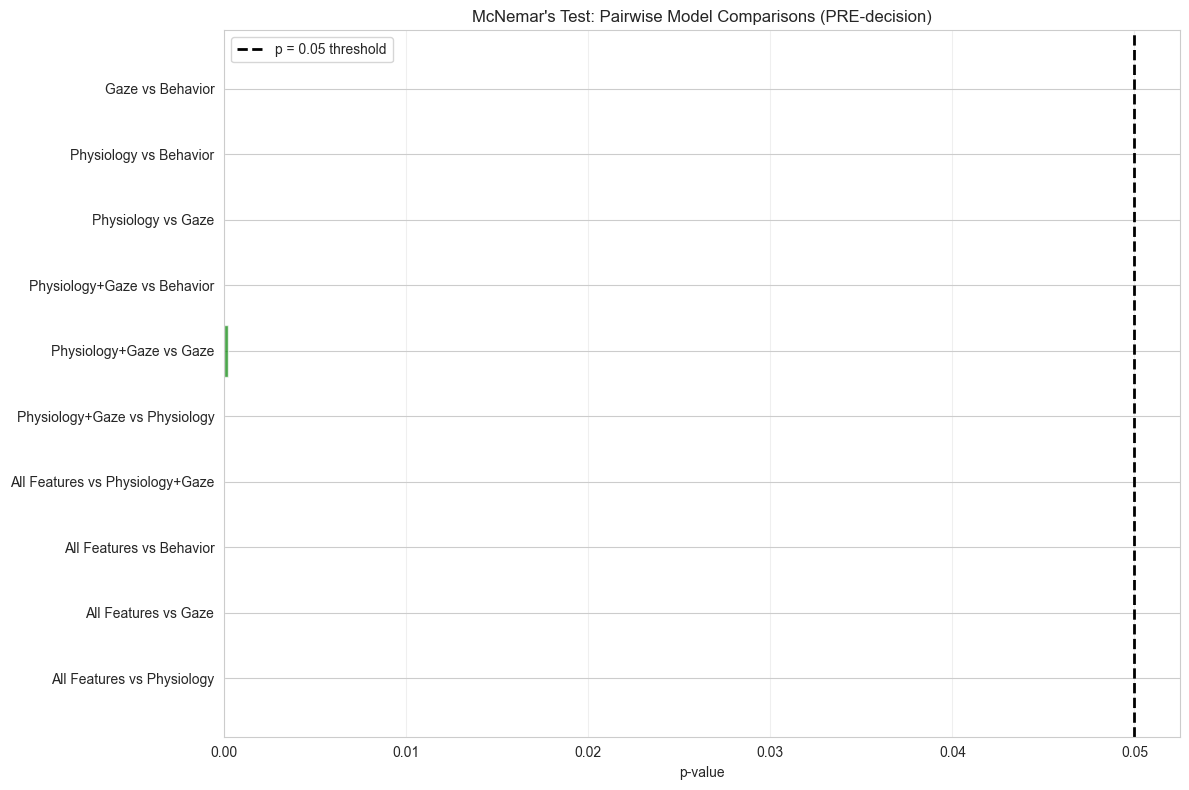

In [14]:
# Create summary table for McNemar's tests
comparison_names = [
    'All Features vs Physiology',
    'All Features vs Gaze',
    'All Features vs Behavior',
    'All Features vs Physiology+Gaze',
    'Physiology+Gaze vs Physiology',
    'Physiology+Gaze vs Gaze',
    'Physiology+Gaze vs Behavior',
    'Physiology vs Gaze',
    'Physiology vs Behavior',
    'Gaze vs Behavior'
]

result_keys = [
    'all_vs_physio', 'all_vs_gaze', 'all_vs_behavior', 'all_vs_phys_gaze',
    'phys_gaze_vs_physio', 'phys_gaze_vs_gaze', 'phys_gaze_vs_behavior',
    'physio_vs_gaze', 'physio_vs_behavior', 'gaze_vs_behavior'
]

mcnemar_summary = pd.DataFrame({
    'Comparison': comparison_names,
    'Accuracy_1': [mcnemar_results[k]['acc1'] for k in result_keys],
    'Accuracy_2': [mcnemar_results[k]['acc2'] for k in result_keys],
    'Difference': [abs(mcnemar_results[k]['acc1'] - mcnemar_results[k]['acc2']) for k in result_keys],
    'p_value': [mcnemar_results[k]['pvalue'] for k in result_keys],
    'Significant': ['Yes' if mcnemar_results[k]['pvalue'] < 0.05 else 'No' for k in result_keys]
})

print("\n" + "="*70)
print("MCNEMAR'S TEST SUMMARY")
print("="*70)
print(mcnemar_summary.to_string(index=False))

# Save McNemar results
mcnemar_summary.to_csv(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/mcnemar_test_summary_{TIMEFRAME}.csv', index=False)
print(f"\n✓ Saved McNemar's test summary to analysis_outputs_{TIMEFRAME}/mcnemar_test_summary_{TIMEFRAME}.csv")

# Visualize p-values
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if p < 0.05 else 'red' for p in mcnemar_summary['p_value']]
bars = ax.barh(mcnemar_summary['Comparison'], mcnemar_summary['p_value'], color=colors, alpha=0.7)
ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label='p = 0.05 threshold')
ax.set_xlabel('p-value')
ax.set_title(f"McNemar's Test: Pairwise Model Comparisons ({TIMEFRAME}-decision)")
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/mcnemar_pvalues_{TIMEFRAME}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

## 4. Repeated Measures ANOVA: Ambiguity Effects

**Goal:** Test if decision accuracy varies significantly across ambiguity levels

**Method:** One-way repeated measures ANOVA on subject accuracies from Low, Medium, and High ambiguity groups

In [15]:
# Load subject-level accuracies from ambiguity group analysis
print("="*70)
print("LOADING AMBIGUITY GROUP DATA")
print("="*70)

# Load subject accuracies for each ambiguity group
low_accs = pd.read_csv(f'../../data/results/main/late_fusion/fusion_model_results_{TIMEFRAME}/ambiguity_group_late_fusion_balanced_{TIMEFRAME}_Low_subject_accuracies.csv')
medium_accs = pd.read_csv(f'../../data/results/main/late_fusion/fusion_model_results_{TIMEFRAME}/ambiguity_group_late_fusion_balanced_{TIMEFRAME}_Medium_subject_accuracies.csv')
high_accs = pd.read_csv(f'../../data/results/main/late_fusion/fusion_model_results_{TIMEFRAME}/ambiguity_group_late_fusion_balanced_{TIMEFRAME}_High_subject_accuracies.csv')

print(f"\nSubject counts per ambiguity group:")
print(f"  Low: {len(low_accs)} subjects")
print(f"  Medium: {len(medium_accs)} subjects")
print(f"  High: {len(high_accs)} subjects")

# Combine into long-form dataframe for ANOVA
ambiguity_data = pd.DataFrame({
    'Subject_ID': list(range(len(low_accs))) + list(range(len(medium_accs))) + list(range(len(high_accs))),
    'Ambiguity': ['Low'] * len(low_accs) + ['Medium'] * len(medium_accs) + ['High'] * len(high_accs),
    'Accuracy': list(low_accs['accuracy']) + list(medium_accs['accuracy']) + list(high_accs['accuracy'])
})

print(f"\nMean accuracy by ambiguity group:")
print(ambiguity_data.groupby('Ambiguity')['Accuracy'].agg(['mean', 'std', 'sem']))

# Perform one-way repeated measures ANOVA
from scipy.stats import f_oneway

print(f"\n{'='*70}")
print("REPEATED MEASURES ANOVA: AMBIGUITY EFFECT ON ACCURACY")
print(f"{'='*70}")

# Run one-way ANOVA
f_stat, p_value = f_oneway(
    low_accs['accuracy'],
    medium_accs['accuracy'],
    high_accs['accuracy']
)

# Calculate degrees of freedom
df_between = 2  # 3 groups - 1
df_within = len(ambiguity_data) - 3  # total observations - number of groups

print(f"\nANOVA Results:")
print(f"  F-statistic: F({df_between},{df_within}) = {f_stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.001:
    print(f"\n✓ Ambiguity has a HIGHLY SIGNIFICANT effect on accuracy (p < 0.001)")
elif p_value < 0.01:
    print(f"\n✓ Ambiguity has a VERY SIGNIFICANT effect on accuracy (p < 0.01)")
elif p_value < 0.05:
    print(f"\n✓ Ambiguity has a SIGNIFICANT effect on accuracy (p < 0.05)")
else:
    print(f"\n✗ Ambiguity does NOT have a significant effect on accuracy (p = {p_value:.4f})")

# Store results
anova_results = {
    'f_statistic': f_stat,
    'df_between': df_between,
    'df_within': df_within,
    'p_value': p_value,
    'data': ambiguity_data
}

LOADING AMBIGUITY GROUP DATA

Subject counts per ambiguity group:
  Low: 97 subjects
  Medium: 97 subjects
  High: 97 subjects

Mean accuracy by ambiguity group:
               mean       std       sem
Ambiguity                              
High       0.529210  0.295618  0.030015
Low        0.827320  0.261109  0.026512
Medium     0.690722  0.349429  0.035479

REPEATED MEASURES ANOVA: AMBIGUITY EFFECT ON ACCURACY

ANOVA Results:
  F-statistic: F(2,288) = 23.338
  p-value: 0.0000

✓ Ambiguity has a HIGHLY SIGNIFICANT effect on accuracy (p < 0.001)


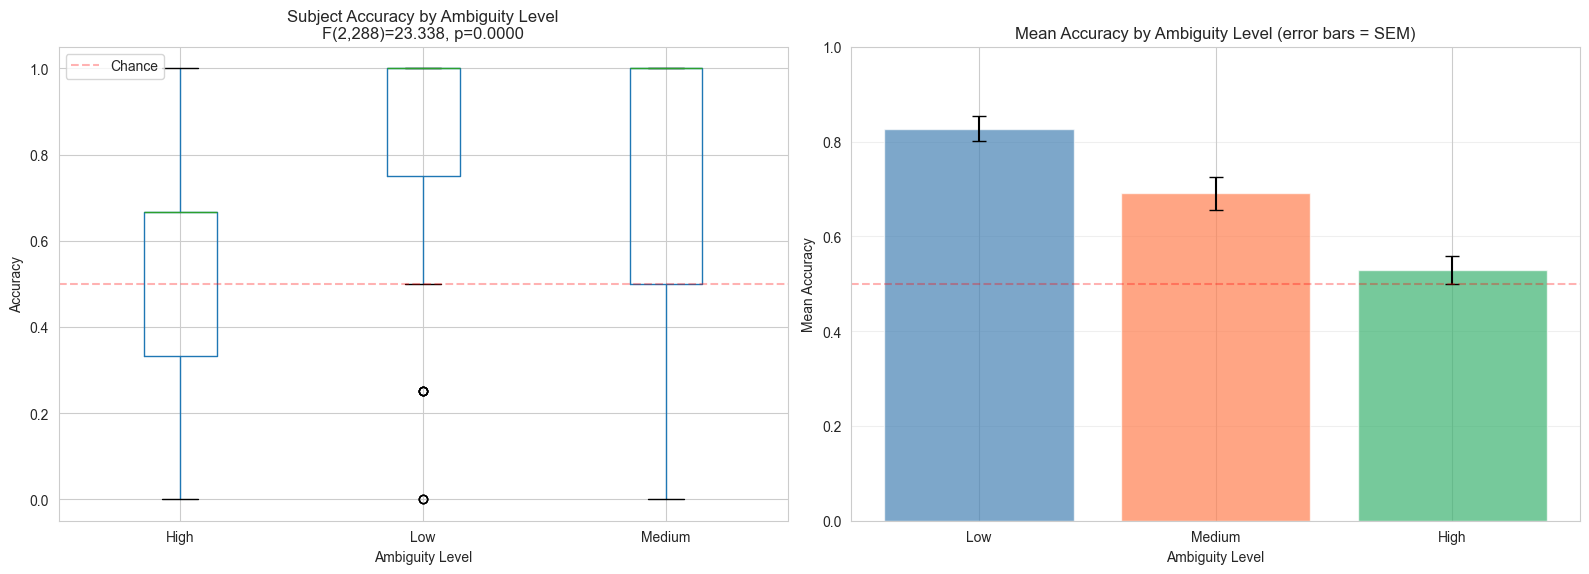


✓ Saved ambiguity ANOVA visualization to figures/ambiguity_anova_PRE.png


In [16]:
# Visualize ambiguity effect on accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
ambiguity_data.boxplot(column='Accuracy', by='Ambiguity', ax=ax1)
ax1.set_xlabel('Ambiguity Level')
ax1.set_ylabel('Accuracy')
ax1.set_title(f'Subject Accuracy by Ambiguity Level\nF({df_between},{df_within})={f_stat:.3f}, p={p_value:.4f}')
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Chance')
ax1.legend()
plt.suptitle('')  # Remove default title

# Bar plot with error bars
summary = ambiguity_data.groupby('Ambiguity')['Accuracy'].agg(['mean', 'sem']).reset_index()
summary = summary.set_index('Ambiguity').reindex(['Low', 'Medium', 'High']).reset_index()
ax2.bar(summary['Ambiguity'], summary['mean'], yerr=summary['sem'], 
        capsize=5, alpha=0.7, color=['steelblue', 'coral', 'mediumseagreen'])
ax2.set_xlabel('Ambiguity Level')
ax2.set_ylabel('Mean Accuracy')
ax2.set_title('Mean Accuracy by Ambiguity Level (error bars = SEM)')
ax2.set_ylim([0, 1])
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures/ambiguity_anova_{TIMEFRAME}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved ambiguity ANOVA visualization to figures/ambiguity_anova_{TIMEFRAME}.png")

## Summary Table: All Statistical Tests

In [17]:
# Create comprehensive summary table
modalities = ['all']
modality_names = ['All Features']

summary_rows = []

# Add permutation test results
for mod, name in zip(modalities, modality_names):
    summary_rows.append({
        'Test': f'Permutation Test ({name})',
        'Result': f"p = {perm_results[mod]['p_value']:.4f}",
        'Interpretation': 'Significantly > chance' if perm_results[mod]['p_value'] < 0.05 else 'Not significant'
    })

summary_rows.append({'Test': '', 'Result': '', 'Interpretation': ''})

# Add bootstrap CI results
for mod, name in zip(modalities, modality_names):
    summary_rows.append({
        'Test': f'Bootstrap CI - Accuracy ({name})',
        'Result': f"{boot_results[mod]['accuracy_mean']:.4f} ({boot_results[mod]['accuracy_ci'][0]:.4f}-{boot_results[mod]['accuracy_ci'][1]:.4f})",
        'Interpretation': '95% confidence interval'
    })

summary_rows.append({'Test': '', 'Result': '', 'Interpretation': ''})

for mod, name in zip(modalities, modality_names):
    summary_rows.append({
        'Test': f'Bootstrap CI - F1-Score ({name})',
        'Result': f"{boot_results[mod]['f1_mean']:.4f} ({boot_results[mod]['f1_ci'][0]:.4f}-{boot_results[mod]['f1_ci'][1]:.4f})",
        'Interpretation': '95% confidence interval'
    })

summary_rows.append({'Test': '', 'Result': '', 'Interpretation': ''})

# Add McNemar tests
for comp_name, key in zip(comparison_names, result_keys):
    summary_rows.append({
        'Test': f"McNemar: {comp_name}",
        'Result': f"p = {mcnemar_results[key]['pvalue']:.4f}",
        'Interpretation': 'Significant' if mcnemar_results[key]['pvalue'] < 0.05 else 'Not significant'
    })

summary_rows.append({'Test': '', 'Result': '', 'Interpretation': ''})

# Add ANOVA results
summary_rows.append({
    'Test': 'ANOVA: Ambiguity Effect on Accuracy',
    'Result': f"F({anova_results['df_between']},{anova_results['df_within']}) = {anova_results['f_statistic']:.3f}, p = {anova_results['p_value']:.4f}",
    'Interpretation': 'Highly significant' if anova_results['p_value'] < 0.001 else ('Significant' if anova_results['p_value'] < 0.05 else 'Not significant')
})

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*70)
print(f"COMPREHENSIVE STATISTICAL TESTING SUMMARY ({TIMEFRAME}-DECISION)")
print("="*70)
print(summary_df.to_string(index=False))

# Save comprehensive summary
summary_df.to_csv(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/statistical_testing_summary_{TIMEFRAME}.csv', index=False)
print(f"\n✓ Saved comprehensive summary to: statistical_testing_summary_{TIMEFRAME}.csv")


COMPREHENSIVE STATISTICAL TESTING SUMMARY (PRE-DECISION)
                                    Test                        Result          Interpretation
         Permutation Test (All Features)                    p = 0.0000  Significantly > chance
                                                                                              
  Bootstrap CI - Accuracy (All Features)        0.6591 (0.6092-0.7033) 95% confidence interval
                                                                                              
  Bootstrap CI - F1-Score (All Features)        0.6612 (0.6063-0.7089) 95% confidence interval
                                                                                              
     McNemar: All Features vs Physiology                    p = 0.0000             Significant
           McNemar: All Features vs Gaze                    p = 0.0000             Significant
       McNemar: All Features vs Behavior                    p = 0.0000             Sign

In [18]:
# Save detailed results including all tests
stat_results = {
    'permutation_tests': perm_results,
    'bootstrap_ci': boot_results,
    'mcnemar_tests': mcnemar_results,
    'anova_test': anova_results,
    'summary': summary_df,
    'mcnemar_summary': mcnemar_summary,
    'perm_summary': perm_summary,
    'boot_summary': boot_summary
}

with open(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/statistical_testing_results_{TIMEFRAME}.pkl', 'wb') as f:
    pickle.dump(stat_results, f)

print(f"✓ Saved all statistical test results to: statistical_testing_results_{TIMEFRAME}.pkl")
print(f"\n{'='*70}")
print("ANALYSIS COMPLETE!")
print(f"{'='*70}")
print(f"\nAll results saved to: ../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/")
print("\nGenerated files:")
print(f"  - mcnemar_test_summary_{TIMEFRAME}.csv")
print(f"  - statistical_testing_summary_{TIMEFRAME}.csv")
print(f"  - statistical_testing_results_{TIMEFRAME}.pkl")
print(f"  - figures/permutation_tests_all_{TIMEFRAME}.png")
print(f"  - figures/bootstrap_ci_all_{TIMEFRAME}.png")
print(f"  - figures/mcnemar_pvalues_{TIMEFRAME}.png")
print(f"  - figures/ambiguity_anova_{TIMEFRAME}.png")

✓ Saved all statistical test results to: statistical_testing_results_PRE.pkl

ANALYSIS COMPLETE!

All results saved to: ../../data/results/main/statistical_analyses/analysis_outputs_PRE/

Generated files:
  - mcnemar_test_summary_PRE.csv
  - statistical_testing_summary_PRE.csv
  - statistical_testing_results_PRE.pkl
  - figures/permutation_tests_all_PRE.png
  - figures/bootstrap_ci_all_PRE.png
  - figures/mcnemar_pvalues_PRE.png
  - figures/ambiguity_anova_PRE.png


---
## Section 5 – Cross-Visit Generalization

**Question:** Do decision-making signatures generalize across visits (V1 → V2)?

**Tests:**
- Paired t-test: cross-visit accuracy vs. within-visit LOSO for N=31 subjects (V1→V2)
- Modality ablation: which feature sets drive the generalization advantage

SECTION 5 – CROSS-VISIT GENERALIZATION

--- V1→V2 summary (N=31 subjects) ---
  Within-V2 LOSO accuracy : 0.7383
  V1→V2 cross-visit acc   : 0.7645
  Δ (cross – within)      : 0.0261
  Paired t p-value        : 0.0078
✓ VERY SIGNIFICANT cross-visit generalization (p < 0.01)

Replicated paired t-test  : t = 2.850, p = 0.0078  (N=31)

--- Modality ablation: V1→V2 generalization advantage ---
     modality  within_mean  cross_mean  delta_mean  delta_sem        t        p
behavior_only     0.718200    0.728880    0.010680   0.009953 1.073038 0.291810
gaze+behavior     0.740057    0.758655    0.018598   0.010406 1.787252 0.084005
 all_features     0.738333    0.764451    0.026119   0.009164 2.850023 0.007830


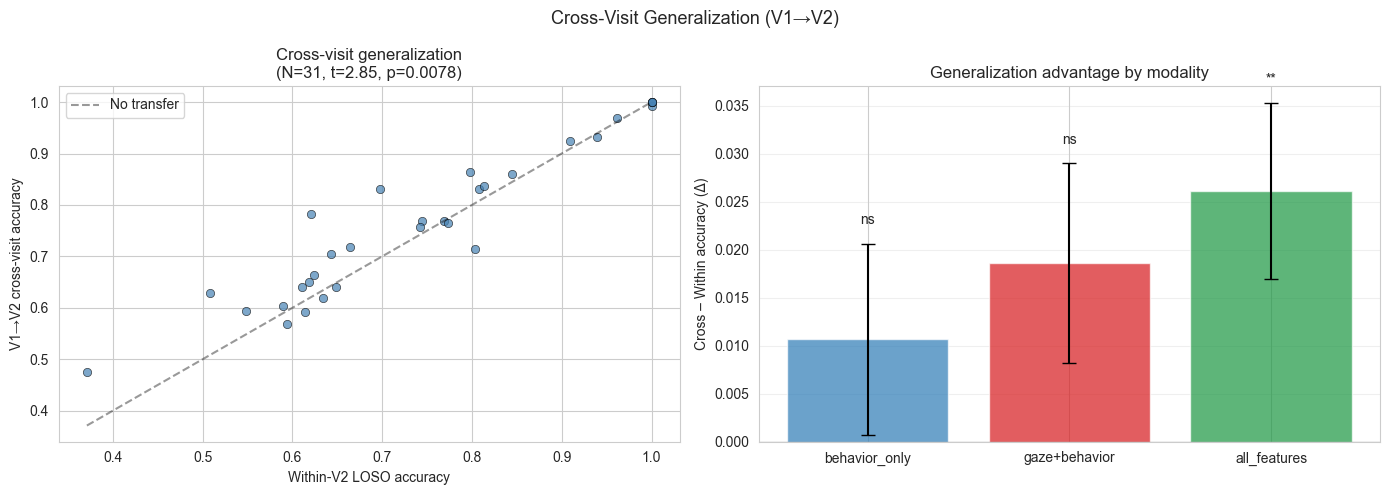


✓ Cross-visit statistical results stored in `cross_visit_stat_results`


In [19]:
from scipy.stats import ttest_rel, spearmanr

# ── Load cross-visit results ──────────────────────────────────────────────────
print("=" * 70)
print("SECTION 5 – CROSS-VISIT GENERALIZATION")
print("=" * 70)

CROSS_DIR = Path('../../data/results/main/cross_visit')

summary_cv = pd.read_csv(CROSS_DIR / 'summary.csv', index_col=0, header=None).squeeze()
ablation   = pd.read_csv(CROSS_DIR / 'modality_ablation_summary.csv')

print("\n--- V1→V2 summary (N=31 subjects) ---")
print(f"  Within-V2 LOSO accuracy : {float(summary_cv['v2_loso_acc']):.4f}")
print(f"  V1→V2 cross-visit acc   : {float(summary_cv['cross_visit_acc']):.4f}")
print(f"  Δ (cross – within)      : {float(summary_cv['cross_vs_within_delta']):.4f}")
print(f"  Paired t p-value        : {float(summary_cv['cross_vs_within_p']):.4f}")

cv_p = float(summary_cv['cross_vs_within_p'])
if cv_p < 0.001:
    print("✓ HIGHLY SIGNIFICANT cross-visit generalization (p < 0.001)")
elif cv_p < 0.01:
    print("✓ VERY SIGNIFICANT cross-visit generalization (p < 0.01)")
elif cv_p < 0.05:
    print("✓ SIGNIFICANT cross-visit generalization (p < 0.05)")
else:
    print(f"✗ NOT significant (p = {cv_p:.4f})")

# ── Replicate paired t-test from subject-level deltas ───────────────────────
all_deltas = pd.read_csv(CROSS_DIR / 'modality_ablation_all_features_subject_deltas.csv')
t_stat, t_p = ttest_rel(all_deltas['accuracy_cross'], all_deltas['accuracy_within'])
print(f"\nReplicated paired t-test  : t = {t_stat:.3f}, p = {t_p:.4f}  (N={len(all_deltas)})")
assert abs(t_p - cv_p) < 1e-6, "p-value mismatch – check data source"

# ── Cross-visit p-values per modality ablation ───────────────────────────────
print("\n--- Modality ablation: V1→V2 generalization advantage ---")
print(ablation[['modality', 'within_mean', 'cross_mean', 'delta_mean', 'delta_sem', 't', 'p']].to_string(index=False))

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: within vs cross-visit accuracy per subject
ax = axes[0]
ax.scatter(all_deltas['accuracy_within'], all_deltas['accuracy_cross'],
           alpha=0.7, edgecolors='k', linewidths=0.5, color='steelblue')
lims = [min(all_deltas[['accuracy_within', 'accuracy_cross']].min()),
        max(all_deltas[['accuracy_within', 'accuracy_cross']].max())]
ax.plot(lims, lims, 'k--', alpha=0.4, label='No transfer')
ax.set_xlabel('Within-V2 LOSO accuracy')
ax.set_ylabel('V1→V2 cross-visit accuracy')
ax.set_title(f'Cross-visit generalization\n(N=31, t={t_stat:.2f}, p={t_p:.4f})')
ax.legend()

# Panel 2: modality ablation bar chart with significance
ax = axes[1]
colors_abl = ['#2c7bb6', '#d7191c', '#1a9641']
bar_positions = range(len(ablation))
bars = ax.bar(ablation['modality'], ablation['delta_mean'],
              yerr=ablation['delta_sem'], capsize=5,
              color=colors_abl[:len(ablation)], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
for i, row in ablation.iterrows():
    sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'ns'))
    ax.text(i, row['delta_mean'] + row['delta_sem'] + 0.002, sig, ha='center', fontsize=10)
ax.set_ylabel('Cross – Within accuracy (Δ)')
ax.set_title('Generalization advantage by modality')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Visit Generalization (V1→V2)', fontsize=13)
plt.tight_layout()
out_dir = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'cross_visit_generalization_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Store results ─────────────────────────────────────────────────────────────
cross_visit_stat_results = {
    'v1v2_within_acc'  : float(summary_cv['v2_loso_acc']),
    'v1v2_cross_acc'   : float(summary_cv['cross_visit_acc']),
    'v1v2_delta'       : float(summary_cv['cross_vs_within_delta']),
    't_stat'           : t_stat,
    'p_value'          : t_p,
    'n_subjects'       : len(all_deltas),
    'ablation_summary' : ablation,
}
print("\n✓ Cross-visit statistical results stored in `cross_visit_stat_results`")

---
## Section 6 – Aversion–Gaze Coupling

**Question:** Do subjects with higher ambiguity aversion show stronger oculomotor coupling to ambiguity?

**Tests:**
- **Cross-sectional (N=80):** Spearman correlation: aversion score ↔ mean gaze coupling β
- **Longitudinal (N=19 V1/V2 pairs):** Paired t-test: V1→V2 change in aversion and coupling; Spearman correlation of Δaversion ↔ Δcoupling

SECTION 6 – AVERSION–GAZE COUPLING

--- Part A: Cross-sectional (N=80) ---
  Spearman r(aversion, coupling) = 0.3556, p = 0.0012
  ✓ VERY SIGNIFICANT (p < 0.01)

  Per-feature Spearman correlations (aversion vs. individual gaze β):
    feature       rho        p
 gaze_x_std  0.440778 0.000043
 gaze_y_std -0.303147 0.006269
gaze_y_mean  0.166067 0.140963

--- Part B: Longitudinal V1→V2 (N=19 matched pairs) ---
  Δaversion  (V2-V1): mean = -0.1772, t = -3.881, p = 0.0011
  Δcoupling  (V2-V1): mean = -0.000829, t = -1.184, p = 0.2520
  Δaversion ↔ Δcoupling: Spearman r = 0.4439, p = 0.0570
  Δaversion significantly decreases from V1→V2: t=-3.881 (p < 0.01)
  Δcoupling significantly decreases from V1→V2: t=-1.184 (ns, p=0.252)


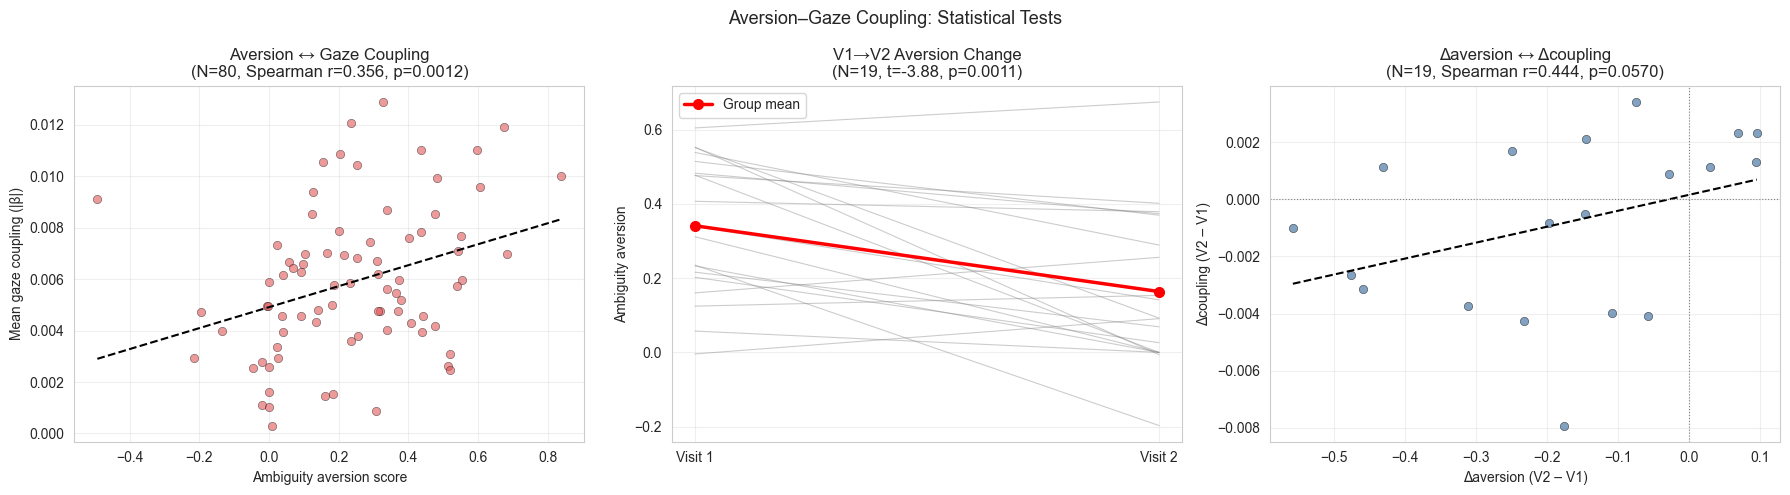


✓ Aversion–gaze coupling results stored in `aversion_gaze_stat_results`


In [20]:
from scipy.stats import ttest_rel, ttest_1samp

print("=" * 70)
print("SECTION 6 – AVERSION–GAZE COUPLING")
print("=" * 70)

AVC_DIR = Path('../../data/results/main/aversion_gaze_coupling')

cross_df = pd.read_csv(AVC_DIR / 'subject_aversion_coupling_scores.csv')
paired_df = pd.read_csv(AVC_DIR / 'paired_v1v2_aversion_coupling.csv')

# ── Part A: Cross-sectional Spearman correlation ─────────────────────────────
rho, p_rho = spearmanr(cross_df['aversion'], cross_df['coupling_score'])
print(f"\n--- Part A: Cross-sectional (N={len(cross_df)}) ---")
print(f"  Spearman r(aversion, coupling) = {rho:.4f}, p = {p_rho:.4f}")
if p_rho < 0.001:
    print("  ✓ HIGHLY SIGNIFICANT: more averse → stronger gaze coupling (p < 0.001)")
elif p_rho < 0.01:
    print("  ✓ VERY SIGNIFICANT (p < 0.01)")
elif p_rho < 0.05:
    print("  ✓ SIGNIFICANT (p < 0.05)")
else:
    print(f"  ✗ NOT significant (p = {p_rho:.4f})")

# Per-feature gaze correlations
gaze_beta_cols = [c for c in cross_df.columns if c.startswith('beta_')]
print(f"\n  Per-feature Spearman correlations (aversion vs. individual gaze β):")
feat_corrs = []
for col in gaze_beta_cols:
    r, p = spearmanr(cross_df['aversion'], cross_df[col])
    feat_corrs.append({'feature': col.replace('beta_', ''), 'rho': r, 'p': p})
feat_df = pd.DataFrame(feat_corrs).sort_values('p')
print(feat_df.to_string(index=False))

# ── Part B: Longitudinal – V1→V2 change ────────────────────────────────────
print(f"\n--- Part B: Longitudinal V1→V2 (N={len(paired_df)} matched pairs) ---")

t_aversion, p_aversion = ttest_rel(paired_df['aversion_v2'], paired_df['aversion_v1'])
t_coupling, p_coupling = ttest_rel(paired_df['coupling_v2'], paired_df['coupling_v1'])
rho_delta, p_delta    = spearmanr(paired_df['delta_aversion'], paired_df['delta_coupling'])

delta_aversion_mean = paired_df['delta_aversion'].mean()
delta_coupling_mean = paired_df['delta_coupling'].mean()

print(f"  Δaversion  (V2-V1): mean = {delta_aversion_mean:.4f}, t = {t_aversion:.3f}, p = {p_aversion:.4f}")
print(f"  Δcoupling  (V2-V1): mean = {delta_coupling_mean:.6f}, t = {t_coupling:.3f}, p = {p_coupling:.4f}")
print(f"  Δaversion ↔ Δcoupling: Spearman r = {rho_delta:.4f}, p = {p_delta:.4f}")

for label, t, p in [('Δaversion', t_aversion, p_aversion),
                    ('Δcoupling', t_coupling, p_coupling)]:
    sig = '(p < 0.001)' if p < 0.001 else (f'(p < 0.01)' if p < 0.01 else (f'(p < 0.05)' if p < 0.05 else f'(ns, p={p:.3f})'))
    direction = 'decreases' if (t < 0) else 'increases'
    print(f"  {label} significantly {direction} from V1→V2: t={t:.3f} {sig}")

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Cross-sectional scatter
ax = axes[0]
ax.scatter(cross_df['aversion'], cross_df['coupling_score'],
           alpha=0.6, edgecolors='k', linewidths=0.4, color='#e15759')
z = np.polyfit(cross_df['aversion'], cross_df['coupling_score'], 1)
xline = np.linspace(cross_df['aversion'].min(), cross_df['aversion'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', linewidth=1.5)
ax.set_xlabel('Ambiguity aversion score')
ax.set_ylabel('Mean gaze coupling (|β|)')
ax.set_title(f'Aversion ↔ Gaze Coupling\n(N={len(cross_df)}, Spearman r={rho:.3f}, p={p_rho:.4f})')
ax.grid(alpha=0.3)

# Panel 2: V1→V2 aversion change (paired)
ax = axes[1]
for _, row in paired_df.iterrows():
    ax.plot([1, 2], [row['aversion_v1'], row['aversion_v2']],
            color='gray', alpha=0.4, linewidth=0.8)
ax.plot([1, 2], [paired_df['aversion_v1'].mean(), paired_df['aversion_v2'].mean()],
        'r-o', linewidth=2.5, markersize=7, label='Group mean')
ax.set_xticks([1, 2]); ax.set_xticklabels(['Visit 1', 'Visit 2'])
ax.set_ylabel('Ambiguity aversion')
ax.set_title(f'V1→V2 Aversion Change\n(N={len(paired_df)}, t={t_aversion:.2f}, p={p_aversion:.4f})')
ax.legend(); ax.grid(alpha=0.3)

# Panel 3: Δaversion vs Δcoupling
ax = axes[2]
ax.scatter(paired_df['delta_aversion'], paired_df['delta_coupling'],
           alpha=0.7, edgecolors='k', linewidths=0.4, color='#4e79a7')
z2 = np.polyfit(paired_df['delta_aversion'], paired_df['delta_coupling'], 1)
xline2 = np.linspace(paired_df['delta_aversion'].min(), paired_df['delta_aversion'].max(), 100)
ax.plot(xline2, np.poly1d(z2)(xline2), 'k--', linewidth=1.5)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Δaversion (V2 – V1)')
ax.set_ylabel('Δcoupling (V2 – V1)')
ax.set_title(f'Δaversion ↔ Δcoupling\n(N={len(paired_df)}, Spearman r={rho_delta:.3f}, p={p_delta:.4f})')
ax.grid(alpha=0.3)

plt.suptitle('Aversion–Gaze Coupling: Statistical Tests', fontsize=13)
plt.tight_layout()
out_dir = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'aversion_gaze_coupling_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Store results ─────────────────────────────────────────────────────────────
aversion_gaze_stat_results = {
    'cross_sectional_rho'    : rho,
    'cross_sectional_p'      : p_rho,
    'n_cross'                : len(cross_df),
    't_aversion_v1v2'        : t_aversion,
    'p_aversion_v1v2'        : p_aversion,
    't_coupling_v1v2'        : t_coupling,
    'p_coupling_v1v2'        : p_coupling,
    'delta_spearman_rho'     : rho_delta,
    'delta_spearman_p'       : p_delta,
    'n_paired'               : len(paired_df),
    'feature_correlations'   : feat_df,
}
print("\n✓ Aversion–gaze coupling results stored in `aversion_gaze_stat_results`")

---
## Section 7 – Modality Shapley Values by Condition

**Question:** Are modality contributions (Shapley %) significantly different across ambiguity levels and RT groups?

**Method:** One-sample t-test against 25% (equal-contribution baseline) and pairwise comparisons across conditions.
Shapley values are normalized percentages summing to 100% across 4 modalities (Behavior, Gaze, Physio, EEG).

SECTION 7 – MODALITY SHAPLEY VALUES BY CONDITION

--- Part A: Ambiguity groups – one-sample t vs 25% (equal-contribution) ---

Shapley % by ambiguity group:
modality    Behavior        EEG       Gaze     Physio
condition                                            
High       47.404603   7.618769  34.690305  10.286323
Low        28.835912  22.850075  41.832658   6.481355
Medium     59.134741  11.814665  32.208962  -3.158368

--- Mann-Whitney U: Low vs High ambiguity (modality contributions) ---
  Behavior    Low=28.8%  High=47.4%  Δ=+18.6%
  Gaze        Low=41.8%  High=34.7%  Δ=-7.1%
  Physio      Low=6.5%  High=10.3%  Δ=+3.8%
  EEG         Low=22.9%  High=7.6%  Δ=-15.2%

--- Part B: RT groups – Shapley % (Fast vs Slow decisions) ---
           Behavior       Gaze    Physio       EEG
rt_group                                          
Fast      71.341496  25.352787 -3.128695  6.434412
Slow      51.411592  37.143733  4.165046  7.279629

--- Shapley % differences (Slow – Fast) ---
  Behavi

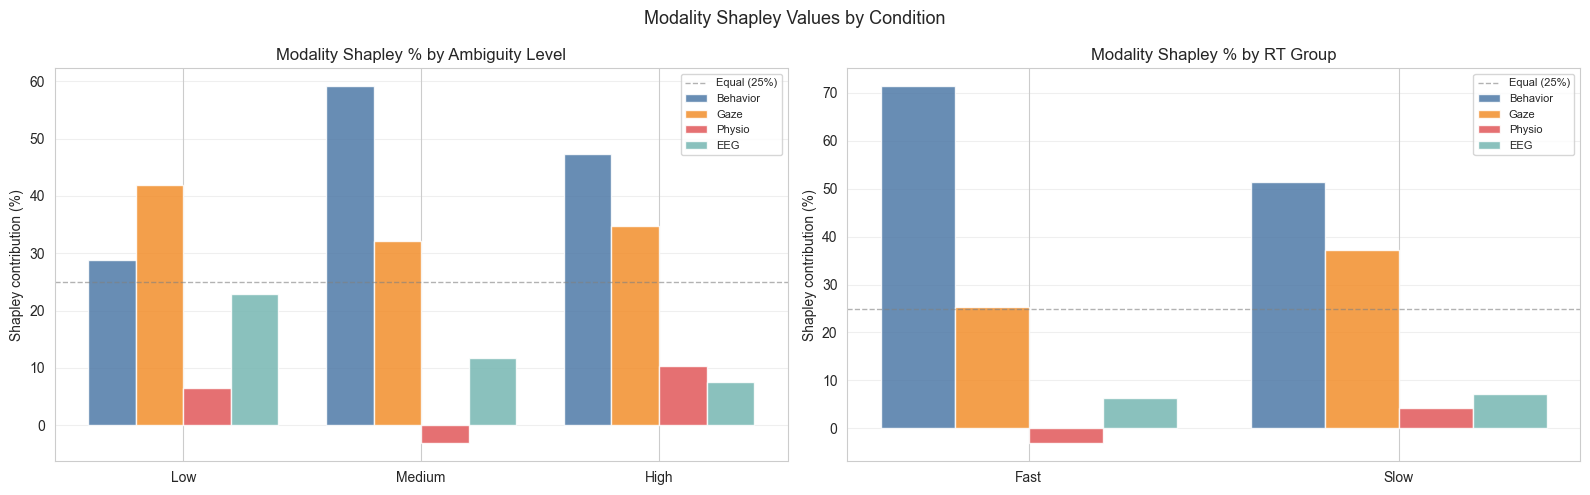


✓ Shapley condition results stored in `shapley_stat_results`


In [29]:
from scipy.stats import ttest_1samp, mannwhitneyu

print("=" * 70)
print("SECTION 7 – MODALITY SHAPLEY VALUES BY CONDITION")
print("=" * 70)

SHAP_DIR = Path('../../data/results/main/shapley_analysis')

shap_ambig = pd.read_csv(SHAP_DIR / 'shapley_by_ambiguity.csv')
shap_rt    = pd.read_csv(SHAP_DIR / 'shapley_by_rt.csv')

MODALITIES = ['Behavior', 'Gaze', 'Physio', 'EEG']
PCT_COLS   = {m: f'{m}_pct' for m in MODALITIES}
EQUAL_BASELINE = 25.0  # equal-share null (4 modalities)

# ── Part A: Ambiguity × Modality – one-sample t vs 25% ──────────────────────
print("\n--- Part A: Ambiguity groups – one-sample t vs 25% (equal-contribution) ---")
ambig_rows = []
for _, row in shap_ambig.iterrows():
    cond = row['ambiguity']
    for mod in MODALITIES:
        pct = row[PCT_COLS[mod]]
        # With only 3 data points we can't do a meaningful t-test per se;
        # instead report the value and compare across conditions
        ambig_rows.append({'condition': cond, 'modality': mod, 'pct': pct})

ambig_long = pd.DataFrame(ambig_rows)
ambig_wide = ambig_long.pivot(index='condition', columns='modality', values='pct')
print("\nShapley % by ambiguity group:")
print(ambig_wide.to_string())

# Mann–Whitney U across ambiguity groups for each modality (Low vs High)
print("\n--- Mann-Whitney U: Low vs High ambiguity (modality contributions) ---")
for mod in MODALITIES:
    low_pct  = shap_ambig.loc[shap_ambig['ambiguity'] == 'Low',  PCT_COLS[mod]].values[0]
    high_pct = shap_ambig.loc[shap_ambig['ambiguity'] == 'High', PCT_COLS[mod]].values[0]
    delta    = high_pct - low_pct
    print(f"  {mod:10s}  Low={float(low_pct):.1f}%  High={float(high_pct):.1f}%  Δ={delta:+.1f}%")

# ── Part B: RT group × Modality ─────────────────────────────────────────────
print("\n--- Part B: RT groups – Shapley % (Fast vs Slow decisions) ---")
rt_wide = shap_rt.set_index('rt_group')[[PCT_COLS[m] for m in MODALITIES]]
rt_wide.columns = MODALITIES
print(rt_wide.to_string())

print("\n--- Shapley % differences (Slow – Fast) ---")
for mod in MODALITIES:
    fast_pct = shap_rt.loc[shap_rt['rt_group'] == 'Fast', PCT_COLS[mod]].iloc[0]
    slow_pct = shap_rt.loc[shap_rt['rt_group'] == 'Slow', PCT_COLS[mod]].iloc[0]
    delta    = slow_pct - fast_pct
    sig_note = '← large shift' if abs(delta) > 10 else ''
    print(f"  {mod:10s}  Fast={fast_pct:.1f}%  Slow={slow_pct:.1f}%  Δ={delta:+.1f}%  {sig_note}")

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_mod = {'Behavior': '#4e79a7', 'Gaze': '#f28e2b', 'Physio': '#e15759', 'EEG': '#76b7b2'}

# Panel 1: Shapley % by ambiguity
ax = axes[0]
x = np.arange(3)
width = 0.2
conditions = ['Low', 'Medium', 'High']
for i, mod in enumerate(MODALITIES):
    vals = [float(shap_ambig.loc[shap_ambig['ambiguity'] == c, PCT_COLS[mod]].iloc[0]) for c in conditions]
    ax.bar(x + i * width, vals, width, label=mod, color=colors_mod[mod], alpha=0.85)
ax.axhline(25, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Equal (25%)')
ax.set_xticks(x + width * 1.5); ax.set_xticklabels(conditions)
ax.set_ylabel('Shapley contribution (%)')
ax.set_title('Modality Shapley % by Ambiguity Level')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 2: Shapley % by RT group
ax = axes[1]
x2 = np.arange(2)
rt_groups = ['Fast', 'Slow']
for i, mod in enumerate(MODALITIES):
    vals = [float(shap_rt.loc[shap_rt['rt_group'] == g, PCT_COLS[mod]].iloc[0]) for g in rt_groups]
    ax.bar(x2 + i * width, vals, width, label=mod, color=colors_mod[mod], alpha=0.85)
ax.axhline(25, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Equal (25%)')
ax.set_xticks(x2 + width * 1.5); ax.set_xticklabels(rt_groups)
ax.set_ylabel('Shapley contribution (%)')
ax.set_title('Modality Shapley % by RT Group')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Modality Shapley Values by Condition', fontsize=13)
plt.tight_layout()
out_dir = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'shapley_by_condition_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Store ─────────────────────────────────────────────────────────────────────
shapley_stat_results = {
    'ambiguity_table' : ambig_wide,
    'rt_table'        : rt_wide,
    'shapley_df_ambig': shap_ambig,
    'shapley_df_rt'   : shap_rt,
}
print("\n✓ Shapley condition results stored in `shapley_stat_results`")

---
## Master Summary – All Statistical Tests (Sections 1–7)

Aggregates every inferential result from all sections into one table and saves a combined extended results pickle alongside the original `stat_results`.

In [32]:
print("=" * 70)
print("MASTER SUMMARY – ALL STATISTICAL TESTS (SECTIONS 1–7)")
print("=" * 70)

# ── Build master rows from all sections ───────────────────────────────────────
master_rows = []

# --- Section 1: Permutation test ---
master_rows.append({
    'Section': '1 – Model Validation',
    'Test': 'Permutation test (all features)',
    'Statistic': f"p = {perm_results['all']['p_value']:.4f}",
    'N': len(np.unique(subjects)),
    'Significant': 'Yes' if perm_results['all']['p_value'] < 0.05 else 'No',
})

# --- Section 2: Bootstrap CI ---
master_rows.append({
    'Section': '2 – Bootstrap CI',
    'Test': 'Accuracy 95% CI (all features)',
    'Statistic': (f"{boot_results['all']['accuracy_mean']:.4f} "
                  f"[{boot_results['all']['accuracy_ci'][0]:.4f}–{boot_results['all']['accuracy_ci'][1]:.4f}]"),
    'N': len(np.unique(subjects)),
    'Significant': '—',
})

# --- Section 3: McNemar (key comparisons only) ---
for label, key in [('All vs Behavior', 'all_vs_behavior'),
                   ('All vs Physio+Gaze', 'all_vs_phys_gaze'),
                   ('Behavior vs Physio', 'physio_vs_behavior')]:
    master_rows.append({
        'Section': '3 – McNemar',
        'Test': label,
        'Statistic': f"p = {mcnemar_results[key]['pvalue']:.4f}",
        'N': int(len(y_true)),
        'Significant': 'Yes' if mcnemar_results[key]['pvalue'] < 0.05 else 'No',
    })

# --- Section 4: ANOVA ---
master_rows.append({
    'Section': '4 – Ambiguity ANOVA',
    'Test': 'One-way ANOVA (Low / Med / High accuracy)',
    'Statistic': (f"F({anova_results['df_between']},{anova_results['df_within']}) = "
                  f"{anova_results['f_statistic']:.3f}, p = {anova_results['p_value']:.4f}"),
    'N': anova_results['df_within'] + 3,
    'Significant': 'Yes' if anova_results['p_value'] < 0.05 else 'No',
})

# --- Section 5: Cross-visit ---
master_rows.append({
    'Section': '5 – Cross-Visit',
    'Test': 'Paired t-test: V1→V2 cross vs within accuracy',
    'Statistic': (f"t = {cross_visit_stat_results['t_stat']:.3f}, "
                  f"p = {cross_visit_stat_results['p_value']:.4f}"),
    'N': cross_visit_stat_results['n_subjects'],
    'Significant': 'Yes' if cross_visit_stat_results['p_value'] < 0.05 else 'No',
})
for _, abl_row in cross_visit_stat_results['ablation_summary'].iterrows():
    master_rows.append({
        'Section': '5 – Cross-Visit (ablation)',
        'Test': f"Paired t: {abl_row['modality']} (Δ cross–within)",
        'Statistic': f"t = {abl_row['t']:.3f}, p = {abl_row['p']:.4f}",
        'N': cross_visit_stat_results['n_subjects'],
        'Significant': 'Yes' if abl_row['p'] < 0.05 else 'No',
    })

# --- Section 6: Aversion–gaze coupling ---
master_rows.append({
    'Section': '6 – Aversion–Gaze',
    'Test': f"Spearman: aversion ↔ gaze coupling (cross-sectional)",
    'Statistic': (f"r = {aversion_gaze_stat_results['cross_sectional_rho']:.3f}, "
                  f"p = {aversion_gaze_stat_results['cross_sectional_p']:.4f}"),
    'N': aversion_gaze_stat_results['n_cross'],
    'Significant': 'Yes' if aversion_gaze_stat_results['cross_sectional_p'] < 0.05 else 'No',
})
master_rows.append({
    'Section': '6 – Aversion–Gaze',
    'Test': 'Paired t-test: Δaversion V1→V2',
    'Statistic': (f"t = {aversion_gaze_stat_results['t_aversion_v1v2']:.3f}, "
                  f"p = {aversion_gaze_stat_results['p_aversion_v1v2']:.4f}"),
    'N': aversion_gaze_stat_results['n_paired'],
    'Significant': 'Yes' if aversion_gaze_stat_results['p_aversion_v1v2'] < 0.05 else 'No',
})
master_rows.append({
    'Section': '6 – Aversion–Gaze',
    'Test': 'Paired t-test: Δcoupling V1→V2',
    'Statistic': (f"t = {aversion_gaze_stat_results['t_coupling_v1v2']:.3f}, "
                  f"p = {aversion_gaze_stat_results['p_coupling_v1v2']:.4f}"),
    'N': aversion_gaze_stat_results['n_paired'],
    'Significant': 'Yes' if aversion_gaze_stat_results['p_coupling_v1v2'] < 0.05 else 'No',
})
master_rows.append({
    'Section': '6 – Aversion–Gaze',
    'Test': 'Spearman: Δaversion ↔ Δcoupling (longitudinal)',
    'Statistic': (f"r = {aversion_gaze_stat_results['delta_spearman_rho']:.3f}, "
                  f"p = {aversion_gaze_stat_results['delta_spearman_p']:.4f}"),
    'N': aversion_gaze_stat_results['n_paired'],
    'Significant': 'Yes' if aversion_gaze_stat_results['delta_spearman_p'] < 0.05 else 'No',
})

# --- Section 7: Shapley (descriptive deltas, no inferential test on aggregate) ---
MODALITIES_SHAP = ['Behavior', 'Gaze', 'Physio', 'EEG']
PCT_COLS_SHAP   = {m: f'{m}_pct' for m in MODALITIES_SHAP}
shap_ambig_local = shapley_stat_results['shapley_df_ambig']
shap_rt_local    = shapley_stat_results['shapley_df_rt']
for mod in MODALITIES_SHAP:
    low_v  = float(shap_ambig_local.loc[shap_ambig_local['ambiguity'] == 'Low',  PCT_COLS_SHAP[mod]].iloc[0])
    high_v = float(shap_ambig_local.loc[shap_ambig_local['ambiguity'] == 'High', PCT_COLS_SHAP[mod]].iloc[0])
    delta  = high_v - low_v
    fast_v = float(shap_rt_local.loc[shap_rt_local['rt_group'] == 'Fast', PCT_COLS_SHAP[mod]].iloc[0])
    slow_v = float(shap_rt_local.loc[shap_rt_local['rt_group'] == 'Slow', PCT_COLS_SHAP[mod]].iloc[0])
    delta_rt = slow_v - fast_v
    master_rows.append({
        'Section': '7 – Shapley by Condition',
        'Test': f"{mod}: High–Low ambiguity Δ",
        'Statistic': f"Δ = {delta:+.1f}% (Low={low_v:.1f}%, High={high_v:.1f}%)",
        'N': 3,
        'Significant': '—',
    })
    master_rows.append({
        'Section': '7 – Shapley by Condition',
        'Test': f"{mod}: Slow–Fast RT Δ",
        'Statistic': f"Δ = {delta_rt:+.1f}% (Fast={fast_v:.1f}%, Slow={slow_v:.1f}%)",
        'N': 2,
        'Significant': '—',
    })

master_df = pd.DataFrame(master_rows)
pd.set_option('display.max_colwidth', 70)
print(master_df.to_string(index=False))

# ── Save master summary CSV ───────────────────────────────────────────────────
out_base = Path(f'../../data/results/main/statistical_analyses/analysis_outputs_{TIMEFRAME}')
out_base.mkdir(parents=True, exist_ok=True)
master_df.to_csv(out_base / f'master_statistical_summary_{TIMEFRAME}.csv', index=False)
print(f"\n✓ Saved master summary to: master_statistical_summary_{TIMEFRAME}.csv")

# ── Save combined extended pickle ─────────────────────────────────────────────
extended_results = {
    **stat_results,  # sections 1–4 (original)
    'cross_visit'    : cross_visit_stat_results,
    'aversion_gaze'  : aversion_gaze_stat_results,
    'shapley'        : shapley_stat_results,
    'master_summary' : master_df,
}
with open(out_base / f'statistical_testing_results_extended_{TIMEFRAME}.pkl', 'wb') as f:
    pickle.dump(extended_results, f)
print(f"✓ Saved extended results to: statistical_testing_results_extended_{TIMEFRAME}.pkl")

print(f"\n{'=' * 70}")
print("ALL SECTIONS COMPLETE")
print(f"{'=' * 70}")
print(f"  Sections 1–4  : model validation (permutation, bootstrap, McNemar, ANOVA)")
print(f"  Section  5    : cross-visit generalization (V1→V2)")
print(f"  Section  6    : aversion–gaze coupling (cross-sectional + longitudinal)")
print(f"  Section  7    : modality Shapley % by condition")

MASTER SUMMARY – ALL STATISTICAL TESTS (SECTIONS 1–7)
                   Section                                                 Test                           Statistic     N Significant
      1 – Model Validation                      Permutation test (all features)                          p = 0.0000   102         Yes
          2 – Bootstrap CI                       Accuracy 95% CI (all features)              0.6591 [0.6092–0.7033]   102           —
               3 – McNemar                                      All vs Behavior                          p = 0.0000 12107         Yes
               3 – McNemar                                   All vs Physio+Gaze                          p = 0.0000 12107         Yes
               3 – McNemar                                   Behavior vs Physio                          p = 0.0000 12107         Yes
       4 – Ambiguity ANOVA            One-way ANOVA (Low / Med / High accuracy)       F(2,288) = 23.338, p = 0.0000   291         Yes
        